## Linear Regression
This is the file where the Linear Regression Model of the Price Prediction Project is implemented. Work here done by Thies


In [27]:
%matplotlib inline
# imports and such
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [4]:
data = pd.read_csv('processed-data/clean-listings.csv')
print(data.shape)
print(data.columns)

(3627, 34)
Index(['listing_id', 'latitude', 'longitude', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'reviews_per_month'],
      dtype='object')


In [5]:
target_column = 'price'

X = data.drop(columns=[target_column, 'listing_id', 'estimated_revenue_l365d'])
y = data[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


(2901,)


(array([442., 567., 505., 580., 484., 348., 185., 126.,  86.,  73.,  47.,
         49.,  19.,  16.,  19.,   8.,   5.,  11.,   2.,   9.,   8.,   4.,
          3.,   7.,   5.,   4.,   0.,   1.,   0.,   0.,   1.,   2.,   2.,
          3.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   1.,   2.,   1.]),
 array([  25.  ,   64.62,  104.24,  143.86,  183.48,  223.1 ,  262.72,
         302.34,  341.96,  381.58,  421.2 ,  460.82,  500.44,  540.06,
         579.68,  619.3 ,  658.92,  698.54,  738.16,  777.78,  817.4 ,
         857.02,  896.64,  936.26,  975.88, 1015.5 , 1055.12, 1094.74,
        1134.36, 1173.98, 1213.6 , 1253.22, 1292.84, 1332.46, 1372.08,
        1411.7 , 1451.32, 1490.94, 1530.56, 1570.18, 1609.8 , 1649.42,
        1689.04, 1728.66, 1768.28, 1807.9 , 1847.52, 1887.14, 1926.76,
        1966.38, 2006.  ]),
 <BarContainer object of 50 artists>)

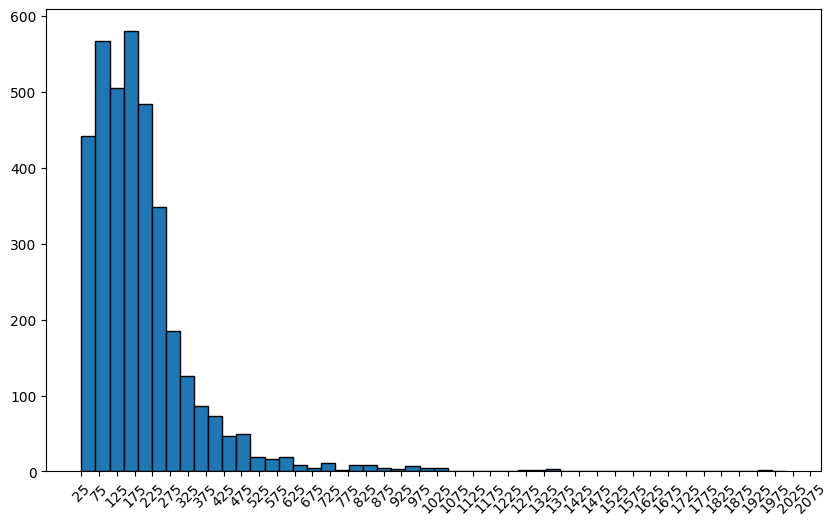

In [6]:
print(y_train.shape)
# price distribution
plt.figure(figsize=(10, 6))
plt.xticks(np.arange(int(y.min()), int(y.max()) + 100, 50), rotation=45)
plt.hist(y, bins=50, edgecolor='black')


In [31]:
regr = LinearRegression()
regr.fit(X_train, y_train)
print("Regression Score: ", regr.score(X_test, y_test))

print("MSE: ", mean_squared_error(y_test, regr.predict(X_test)))

Regression Score:  0.35309607493530937
MSE:  17618.82904494309


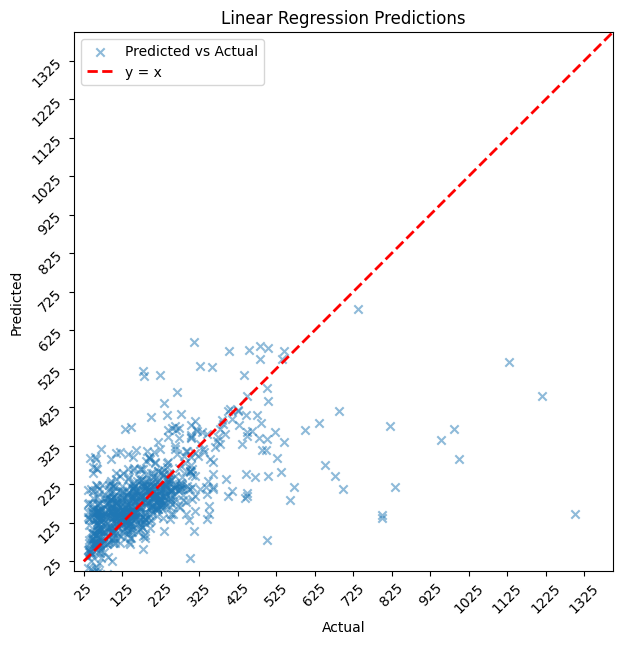

In [24]:
# What we currently see is that the score of the model basically implies its just guessing the average price.
y_pred = regr.predict(X_test)
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred, alpha=0.5, marker='x', label = 'Predicted vs Actual')
plt.xlabel("Actual")
plt.xticks(np.arange(int(y.min()), int(y.max()) + 100, 100), rotation=45)
plt.ylabel("Predicted")
plt.yticks(np.arange(int(y.min()), int(y.max()) + 100, 100), rotation=45)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2, label='y = x')
plt.xlim([0, 1400])
plt.ylim([0, 1400])
plt.legend()
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.title("Linear Regression Predictions")
plt.show()